Claude Opus 5:   0%|          | 0/2000 [00:00<?, ?it/s]

Claude Opus 5: MAE $13.31 | RMSLE 0.390 | R2 45.3% | hits 64.4%


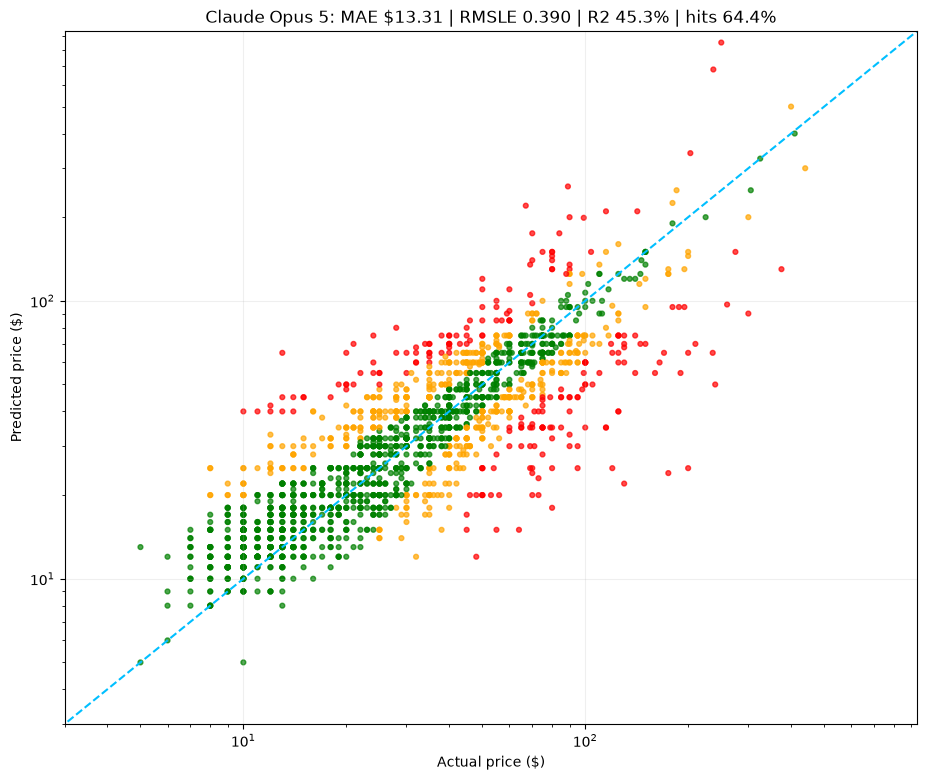

calls 2000 | parse failures 0 | tokens in 500,450 out 6,000
model                                    MAE    RMSLE      R2    hits      n
Claude Opus 5                         13.31    0.390   45.3%   64.4%  2,000
Tf-Idf + Ridge                        15.31    0.454   44.4%   58.9%  2,000
Lsa + Random Forest                   16.57    0.505   34.1%   55.1%  2,000
Classical (note only)                 16.38    0.518   39.0%   57.0%    100
Metadata + Linear Regression          17.40    0.532   29.2%   52.8%  2,000
Neighbours (k=8, retrieval only)      18.49    0.554   32.4%   49.0%    100
Frontier (RAG + LLM)                  20.74    0.639   29.8%   46.0%    100
Constant $30                          23.96    0.749   -7.7%   29.6%  2,000


In [7]:
import os

import re
import threading
import time

from anthropic import Anthropic, RateLimitError, APIStatusError
from dotenv import load_dotenv

from pricer.evaluator import evaluate, leaderboard
from pricer.items import Wine

DATASET = "borjahernandez/wine-pricer"
MODEL = "claude-opus-5"

load_dotenv(override=True)
client = Anthropic(api_key=os.environ["ANTHROPIC_API_KEY"])

SYSTEM = (
    "You estimate the retail price of a bottle of wine from its description.\n"
    "Reply with a number and nothing else -- no currency symbol, no units, no words, "
    "no explanation. Prices in this dataset range from roughly 4 to 1000 dollars."
)

_lock = threading.Lock()
stats = {"calls": 0, "failures": 0, "tokens_in": 0, "tokens_out": 0}


def parse_price(text: str) -> float:
    match = re.search(r"[-+]?\d[\d,]*\.?\d*", text.replace("$", ""))
    if not match:
        return 0.0
    return min(max(float(match.group().replace(",", "")), 0.0), 1000.0)


def extract_text(resp) -> str:
    return "".join(b.text for b in resp.content if b.type == "text")


def ask(prompt: str, attempts: int = 4) -> tuple[str, int, int]:
    for attempt in range(attempts):
        try:
            resp = client.messages.create(
                model=MODEL,
                max_tokens=8,
                system=SYSTEM,
                thinking={"type": "disabled"},
                messages=[{"role": "user", "content": prompt}],
            )
            return extract_text(resp), resp.usage.input_tokens, resp.usage.output_tokens
        except (RateLimitError, APIStatusError):
            if attempt == attempts - 1:
                raise
            time.sleep(2 ** attempt)
    return "", 0, 0


def frontier(wine: Wine) -> float:
    text, tin, tout = ask(wine.test_prompt())
    price = parse_price(text)
    with _lock:
        stats["calls"] += 1
        stats["tokens_in"] += tin
        stats["tokens_out"] += tout
        if price == 0.0:
            stats["failures"] += 1
    return price


_, _, test = Wine.from_hub(DATASET)

frontier.__name__ = "Claude Opus 5"
evaluate(frontier, test, size=2000)
print(f"calls {stats['calls']} | parse failures {stats['failures']} | "
      f"tokens in {stats['tokens_in']:,} out {stats['tokens_out']:,}")
leaderboard()

In [1]:
import anthropic; print(anthropic.__version__)

1.4.0


In [6]:
for w in test[:3]:
    print(repr(ask(w.test_prompt())[0]), "actual:", w.price)

'80' actual: 72.0
'65' actual: 90.0
'17' actual: 18.0


In [8]:
print(len(set(report.guesses)), "distinct predictions out of", len(report.guesses))

NameError: name 'report' is not defined